In [1]:
import os

# set your default path here
os.chdir("/Users/aditya/Downloads/Medisyn_Labs_case_study")

# confirm
print("Current Working Directory:", os.getcwd())


Current Working Directory: /Users/aditya/Downloads/Medisyn_Labs_case_study


Training and testing datasets loaded successfully.
Data preprocessing complete.
Feature vectorization complete.

Model Accuracy on Unseen Test Data: 51.93%

Classification Report:
                        precision    recall  f1-score   support

Considerably Effective       0.43      0.55      0.48       310
      Highly Effective       0.58      0.80      0.68       411
           Ineffective       0.58      0.26      0.36        82
  Marginally Effective       1.00      0.04      0.08        76
  Moderately Effective       0.40      0.09      0.15       157

              accuracy                           0.52      1036
             macro avg       0.60      0.35      0.35      1036
          weighted avg       0.54      0.52      0.47      1036



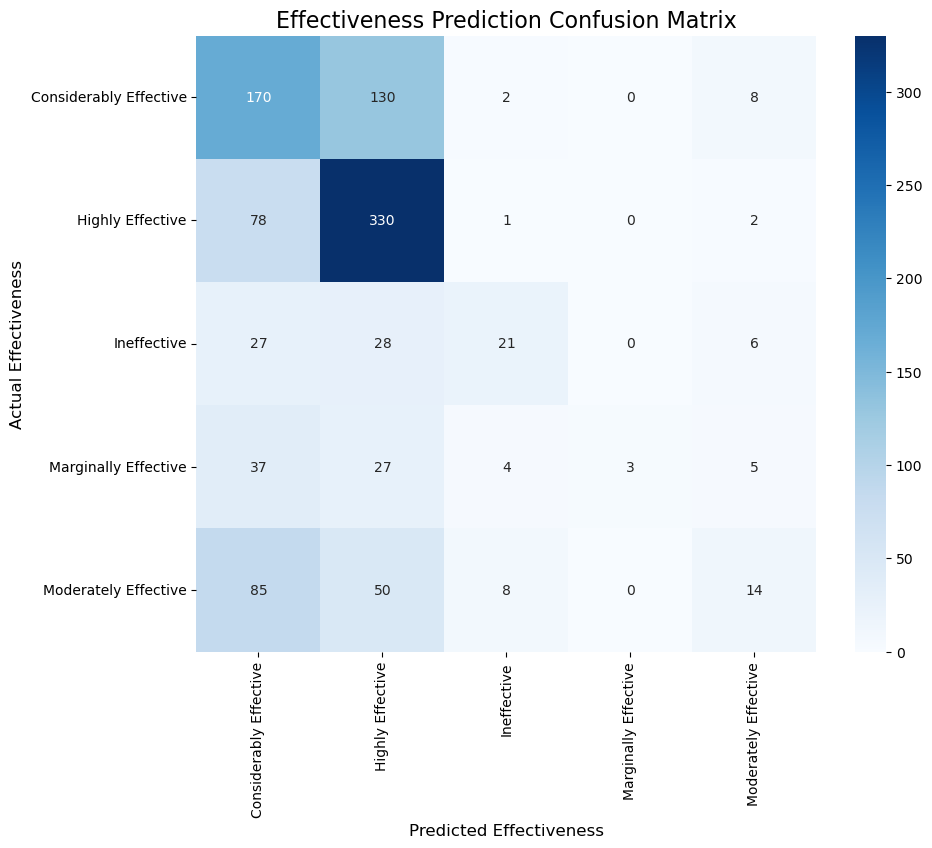

In [2]:
# ==============================================================================
# Step 1: Setup and Data Loading (Separate Train/Test)
# ==============================================================================
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import hstack
import seaborn as sns
import matplotlib.pyplot as plt

# Load the datasets separately
try:
    train_df = pd.read_csv('train.tsv', sep='\t', header=None)
    test_df = pd.read_csv('test.tsv', sep='\t', header=None)
except FileNotFoundError:
    print("Ensure 'train.tsv' and 'test.tsv' are in the same directory.")
    exit()

# Define and assign column names
column_names = [
    'CustomerID', 'Medicine', 'Rating', 'Effectiveness', 'Side Effects',
    'Condition', 'Benefits', 'Side Effects Review', 'Comments'
]
train_df.columns = column_names
test_df.columns = column_names

print("Training and testing datasets loaded successfully.")

# ==============================================================================
# Step 2: Preprocessing and Feature Engineering
# ==============================================================================
# This function will prepare our text and numerical data for the model.

def preprocess_data(df):
    # Combine all review columns into a single text feature
    df['review_text'] = df['Benefits'].fillna('') + ' ' + \
                        df['Side Effects Review'].fillna('') + ' ' + \
                        df['Comments'].fillna('')

    # Clean the combined text
    df['cleaned_review'] = df['review_text'].apply(
        lambda text: re.sub(f'[{re.escape(string.punctuation)}]', '', text.lower())
    )

    # Define the features (X) and the target variable (y)
    X = df[['cleaned_review', 'Rating']]
    y = df['Effectiveness']
    return X, y

X_train, y_train = preprocess_data(train_df)
X_test, y_test = preprocess_data(test_df)

print("Data preprocessing complete.")

# ==============================================================================
# Step 3: Vectorize Text and Combine Features
# ==============================================================================
# We must fit the vectorizer ONLY on the training data to prevent data leakage.

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

# Fit on the training text and transform it
X_train_text_vec = vectorizer.fit_transform(X_train['cleaned_review'])

# ONLY transform the test text using the already-fitted vectorizer
X_test_text_vec = vectorizer.transform(X_test['cleaned_review'])

# Combine the vectorized text features with the numerical 'Rating' feature
# .values.reshape(-1,1) is used to ensure the Rating is in the correct shape
X_train_final = hstack([X_train_text_vec, X_train['Rating'].values.reshape(-1,1)])
X_test_final = hstack([X_test_text_vec, X_test['Rating'].values.reshape(-1,1)])

print("Feature vectorization complete.")

# ==============================================================================
# Step 4: Train and Evaluate the Model
# ==============================================================================
# A RandomForestClassifier is a strong choice for this text and numerical data mix.

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)

# Make predictions on the unseen test data
y_pred = model.predict(X_test_final)

# --- Performance Evaluation ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Unseen Test Data: {accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# --- Visualize the Results with a Confusion Matrix ---
plt.figure(figsize=(10, 8))
class_names = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=class_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Effectiveness Prediction Confusion Matrix', fontsize=16)
plt.ylabel('Actual Effectiveness', fontsize=12)
plt.xlabel('Predicted Effectiveness', fontsize=12)
plt.show()

In [3]:
# You can run this to confirm the class imbalance
print("Distribution of Effectiveness Categories:")
print(train_df['Effectiveness'].value_counts())

Distribution of Effectiveness Categories:
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: Effectiveness, dtype: int64


In [4]:
# ==============================================================================
# Step 1: Setup and Data Loading (Separate Train/Test)
# ==============================================================================
import pandas as pd
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

# Load the datasets separately
try:
    train_df = pd.read_csv('train.tsv', sep='\t', header=None)
    test_df = pd.read_csv('test.tsv', sep='\t', header=None)
except FileNotFoundError:
    print("Ensure 'train.tsv' and 'test.tsv' are in the same directory.")
    exit()

# Define and assign column names
column_names = [
    'CustomerID', 'Medicine', 'Rating', 'Effectiveness', 'Side Effects',
    'Condition', 'Benefits', 'Side Effects Review', 'Comments'
]
train_df.columns = column_names
test_df.columns = column_names

# ==============================================================================
# Step 2: Preprocessing and Richer Feature Engineering
# ==============================================================================
# Map Side Effects to a numerical scale
side_effects_map = {
    'No Side Effects': 1, 'Mild Side Effects': 2, 'Moderate Side Effects': 3,
    'Severe Side Effects': 4, 'Extremely Severe Side Effects': 5
}

def preprocess_data(df):
    # Combine review columns
    df['review_text'] = df['Benefits'].fillna('') + ' ' + \
                        df['Side Effects Review'].fillna('') + ' ' + \
                        df['Comments'].fillna('')
    # Clean text
    df['cleaned_review'] = df['review_text'].apply(
        lambda text: re.sub(f'[{re.escape(string.punctuation)}]', '', text.lower())
    )
    # **NEW**: Create numerical Side Effects feature
    df['SideEffects_Num'] = df['Side Effects'].map(side_effects_map)
    df['SideEffects_Num'].fillna(3.0, inplace=True) # Fill missing with the mode (Moderate)

    # Define features (X) and target (y)
    X = df[['cleaned_review', 'Rating', 'SideEffects_Num']]
    y = df['Effectiveness']
    return X, y

X_train, y_train = preprocess_data(train_df)
X_test, y_test = preprocess_data(test_df)

# ==============================================================================
# Step 3: Vectorize Text and Combine All Features
# ==============================================================================
# Vectorize text
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_text_vec = vectorizer.fit_transform(X_train['cleaned_review'])
X_test_text_vec = vectorizer.transform(X_test['cleaned_review'])

# Scale numerical features
scaler = MinMaxScaler()
X_train_num_scaled = scaler.fit_transform(X_train[['Rating', 'SideEffects_Num']])
X_test_num_scaled = scaler.transform(X_test[['Rating', 'SideEffects_Num']])

# Combine text and scaled numerical features
X_train_final = hstack([X_train_text_vec, X_train_num_scaled])
X_test_final = hstack([X_test_text_vec, X_test_num_scaled])

# ==============================================================================
# Step 4: Train and Evaluate the IMPROVED Model
# ==============================================================================
# **IMPROVEMENT**: Add `class_weight='balanced'` to the model
# This tells the model to give more weight to the rare classes.
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # <-- THE KEY IMPROVEMENT
    n_jobs=-1
)
model.fit(X_train_final, y_train)

# Make predictions on the unseen test data
y_pred = model.predict(X_test_final)

# --- Performance Evaluation ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nIMPROVED Model Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


IMPROVED Model Accuracy: 54.25%

Classification Report:
                        precision    recall  f1-score   support

Considerably Effective       0.45      0.45      0.45       310
      Highly Effective       0.63      0.81      0.71       411
           Ineffective       0.46      0.65      0.54        82
  Marginally Effective       0.67      0.05      0.10        76
  Moderately Effective       0.46      0.20      0.28       157

              accuracy                           0.54      1036
             macro avg       0.53      0.43      0.41      1036
          weighted avg       0.54      0.54      0.51      1036

